In [3]:
# ----- ALGORITMO GENETICO-----
import numpy as np 
import matplotlib.pyplot as plt 



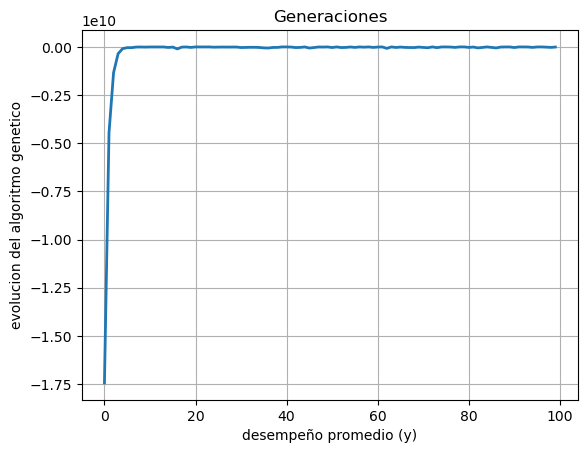

Resultado: x=37.93103448275863, y=189.7986


In [4]:
#-------- inicializacion de la poblacion -------

# definicion de limites y tamaño de paso

xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso


# calculo de elemento y numero de bits

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion


# padres enteros a padres reales
# generar poblacion inicial de enteros

x1 = np.random.randint(0, 2**nbits, num_poblacion)


# transformar de enteros a reales

x1real = (xmax-xmin)*x1 / (2*nbits-1) + xmin


# matriz para almacenar el promedio del desempeño

yprom = np.zeros(100) # zeros crea una matriz de puros 0


#------- iniciar numero de generaciones -------

for i in range(100):

    # evaluar los padres de la funcion objetivo

    y = -(x1real-41.125)**2 + 200 # funcion de fitness
    yprom[i] = np.mean(y)


    # ordenar los cromosomas (de menor a mayor desempeño)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]


    # seleccionar la mitad (los mejores)

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)

    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1


    #-------- cruzamiento-----

    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):

        # elegir el punto de cruzamiento

        n = np.random.randint(1, nbits-1)

        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        # intercambiar informacion para crear hijos binarios

        hijobin[2*k] = np.concatenate((padre1[:n], padre2[n:]))
        hijobin[2*k+1] = np.concatenate((padre2[:n], padre1[n:]))


        #-------- mutacion--------

        p = np.random.rand() # definimos un numero aleatorio entre 0 y 1

        if p > 0.90: # condicion para mutacion (10%)

            # seleccionar aleatoriamente una posicion y un bit

            nhijo = np.random.randint(0, num_poblacion//2)
            nbit = np.random.randint(0, nbits)


            # invertir el valor del bit

            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]


        # ---- reiniciar proceso (decodificacion)----

        # convertir hijo binario a entero

        hijoent = np.zeros(num_poblacion//2)

        for idx in range(num_poblacion//2):

            val = 0

            for j in range(nbits):
                val += hijobin[idx, j] * (2**j)

            hijoent[idx] = val


        # convertir hijo entero a real usando la funcion de conversacion

        hijoreal = (xmax-xmin)*hijoent/(2*nbits-1) + xmin


        # actualizar matrices pasandolo de hijo a padre

        x1 = np.concatenate((mejores_x1, hijoent))
        x1real = np.concatenate((mejores_x1real, hijoreal))


#------- mostrar resultado en pantalla ------

plt.plot(yprom, linewidth=2)

plt.title("Generaciones")
plt.xlabel("desempeño promedio (y)")
plt.ylabel("evolucion del algoritmo genetico")

plt.grid(True)
plt.show()


# evaluar la funcion final para encontrar el maximo

y = -(x1real-41.125)**2 + 200

val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]}, y={val:.4f}")

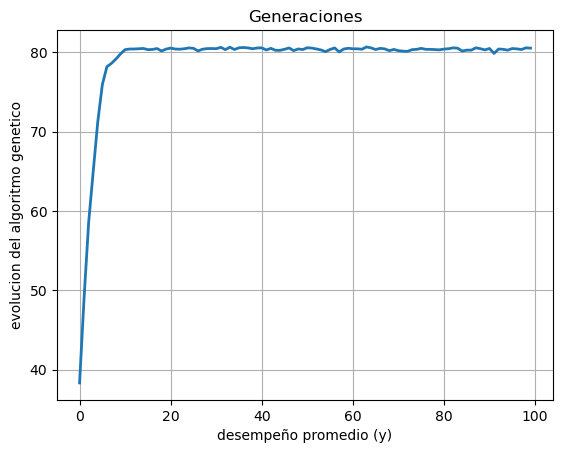

Resultado: x1=-4.5247, x2=-4.5247 ,y=80.7054


In [5]:
#-------- inicializacion de la poblacion -------

# definicion de limites y tamaño de paso

xmin = -5.12 # limite inferior
xmax = 5.12# limite superior
tpaso = 0.01 # tamaño de paso

xmin2 = -5.12 # limite inferior
xmax2 = 5.12# limite superior
tpaso2 = 0.01 # tamaño de paso


# calculo de elemento y numero de bits

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
nbits2 = int(np.ceil(np.log2(elementos)))
num_poblacion = 512 # tamaño de poblacion


# padres enteros a padres reales
# generar poblacion inicial de enteros

x1 = np.random.randint(0, 2**nbits, num_poblacion)
x2=np.random.randint(0, 2**nbits2, num_poblacion)


# transformar de enteros a reales

x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin
x2real=(xmax2-xmin2)*x2 / (2**nbits2-1) + xmin2

# matriz para almacenar el promedio del desempeño

yprom = np.zeros(100) # zeros crea una matriz de puros 0


#------- iniciar numero de generaciones -------

for i in range(100):

    # evaluar los padres de la funcion objetivo

    y = 20+x1real**2+x2real**2-10*np.cos(2*np.pi*x1real)-10*np.cos(2*np.pi*x2real) # funcion de fitness
    yprom[i] = np.mean(y)


    # ordenar los cromosomas (de menor a mayor desempeño)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]
    x2_ordenado=x2[indices_ordenados]
    x2real_ordenado = x2real[indices_ordenados]



    # seleccionar la mitad (los mejores)

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]
    mejores_x2 = x2_ordenado[num_poblacion//2:]
    mejores_x2real = x2real_ordenado[num_poblacion//2:]

    # convertir padres enteros seleccionados a binario

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    padresbin2 = np.zeros((num_poblacion//2, nbits2), dtype=int)

    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1
        for j in range(nbits2):
            padresbin2[idx, j] = (int(val) >> j) & 1        




    #-------- cruzamiento-----

    hijobin = np.zeros_like(padresbin)
    hijobin2 = np.zeros_like(padresbin2)
    

    for k in range(num_poblacion//4):
        # elegir el punto de cruzamiento
        n = np.random.randint(1, nbits-1)
        p1_v1 = padresbin[2*k]
        p2_v1 = padresbin[2*k+1]
        # intercambiar informacion para crear hijos binarios
        hijobin[2*k] = np.concatenate((p1_v1[:n], p2_v1[n:]))
        hijobin[2*k+1] = np.concatenate((p2_v1[:n], p1_v1[n:]))

        n2 = np.random.randint(1, nbits2-1)
        p1_v2 = padresbin[2*k]
        p2_v2 = padresbin[2*k+1]
        # intercambiar informacion para crear hijos binarios
        hijobin2[2*k] = np.concatenate((p1_v2[:n2], p2_v2[n2:]))
        hijobin2[2*k+1] = np.concatenate((p2_v2[:n2], p1_v2[n2:]))


        #-------- mutacion--------

        p = np.random.rand() # definimos un numero aleatorio entre 0 y 1

        if p > 0.90: # condicion para mutacion (10%)
        # seleccionar aleatoriamente una posicion y un bit
            nhijo = np.random.randint(0, num_poblacion//2)
            nbit = np.random.randint(0, nbits)
            # invertir el valor del bit
            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

        if p > 0.90: # condicion para mutacion (10%)
                # seleccionar aleatoriamente una posicion y un bit
                    nhijo = np.random.randint(0, num_poblacion//2)
                    nbit = np.random.randint(0, nbits2)
                    # invertir el valor del bit
                    hijobin2[nhijo, nbit] = 1 - hijobin2[nhijo, nbit]


        # ---- reiniciar proceso (decodificacion)----

        # convertir hijo binario a entero

        hijoent = np.zeros(num_poblacion//2)
        hijoent2 = np.zeros(num_poblacion//2)

        for idx in range(num_poblacion//2):

            val = val2 = 0
            for j in range(nbits):
                val += hijobin[idx, j] * (2**j)
            for j in range(nbits2):
                 val2+=hijobin2[idx, j] * (2**j)
            hijoent[idx],hijoent2[idx] = val,val2


        # convertir hijo entero a real usando la funcion de conversacion

        hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin
        hijoreal2 = (xmax2-xmin2)*hijoent2/(2**nbits2-1) + xmin2


        # actualizar matrices pasandolo de hijo a padre

        x1 = np.concatenate((mejores_x1, hijoent))
        x1real = np.concatenate((mejores_x1real, hijoreal))
        x2 = np.concatenate((mejores_x2, hijoent2))
        x2real = np.concatenate((mejores_x2real, hijoreal2))


#------- mostrar resultado en pantalla ------

plt.plot(yprom, linewidth=2)
plt.title("Generaciones")
plt.xlabel("desempeño promedio (y)")
plt.ylabel("evolucion del algoritmo genetico")
plt.grid(True)
plt.show()


# evaluar la funcion final para encontrar el maximo

y = 20+x1real**2+x2real**2-10*np.cos(2*np.pi*x1real)-10*np.cos(2*np.pi*x2real) 

val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x1={x1real[ind]:.4f}, x2={x2real[ind]:.4f} ,y={val:.4f}")